In [1]:
%pip install -U microlens_submit
%pip install RTModel
%pip install -U jacscanomaly
%pip install -U microjax
%pip install pyAethra

  Using cached microlens_submit-0.17.9-py3-none-any.whl.metadata (10 kB)
Using cached microlens_submit-0.17.9-py3-none-any.whl (1.1 MB)
  Attempting uninstall: microlens_submit
    Found existing installation: microlens-submit 0.16.4
    Uninstalling microlens-submit-0.16.4:
      Successfully uninstalled microlens-submit-0.16.4

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached jacscanomaly-0.5.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached jax-0.10.2-py3-none-any.whl.metadata (13 kB)
  Using cached vbmicrolensing-5.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.7 kB)
  Using cached jaxlib-0.10.2-cp3

Install aethra for event detection: this is still in development by Katie Vandorou https://github.com/rges-pit/aethra/tree/main

In [2]:
# !git clone https://github.com/rges-pit/aethra.git
# %cd aethra
# %pip install -e ".[parquet]"
# #%pip install -e .
# #%cd ..

In [3]:
# import sys
# LOCAL = '/teams/mldc-ipacpeople/nexus-notebooks/notebooks/aethra/src'

# sys.path.insert(0, LOCAL)
# for m in [k for k in sys.modules if k == "aethra" or k.startswith("aethra.")]:
#     del sys.modules[m]

# import aethra
# assert aethra.__file__.startswith(LOCAL), f"still importing {aethra.__file__}"
# print("using:", aethra.__file__)

In [4]:
#import aethra
from pyAethra import load_config, load_and_run

In [5]:
# system imports
import os
import time
import sys
from pathlib import Path

# data access imports
from huggingface_hub import hf_hub_download
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# display imports
from IPython.display import HTML

# multiprocessing imports
import multiprocessing as mp
from multiprocessing.pool import ThreadPool

# data challenge imports
import microlens_submit
#import MulensModel
import emcee
#from pyLIMA.pyLIMASS import SourceLensProbabilities
#%pip install -U RTModel
import RTModel

# data analysis/visualization imports
import numpy as np
import matplotlib.pyplot as plt

# for event detection
#from eventfinder import load_and_run, _read_table_file, run_pipeline_from_dataframe
# for anomaly detection
from jacscanomaly import CandidateCriteria, Finder, FinderConfig

In [6]:
RTModel.__version__

'3.0'

In [7]:
TIER = "Beginner"
REPO_ID = f"RGES-PIT/{TIER}"

FILENAME = f"RMDC26_{TIER}_Tier_test.parquet"  # "_test" tells hugging face this is not a machine learning training set.
local_data_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
lc_data_all = pd.read_parquet(local_data_path)
print(local_data_path)
print(lc_data_all)
print(lc_data_all.columns)
print(lc_data_all['name'])

### this is for Kyle
#lc_data_all.to_csv("~/beginner.parquet", index=False)

/home/mldc-ipacpeople-admin/.cache/huggingface/hub/datasets--RGES-PIT--Beginner/snapshots/3d091e68f83662a843c9a5ef78b913c1b0e30848/RMDC26_Beginner_Tier_test.parquet
                  name     l_deg     b_deg      ra_deg    dec_deg  \
0        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
1        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
2        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
3        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
4        RMDC26_000001 -0.209139 -1.912896  268.166250 -30.099826   
...                ...       ...       ...         ...        ...   
9230043  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230044  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230045  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230046  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   
9230047  RMDC26_000188  1.502443 -2.015421  269.258049 -28.674454   

      

Normally, we'd take a bunch of light curves and do event detection straight-up. But the data challenge light curves all have the same time stamps, so the best we can do is to iterate one light curve at a time and do event detection --> anomaly detection --> event modeling per "light curve" (but really per event). So, this isn't super representative of our ability to do event detection (or anomaly detection?). 

Especially for RTModel to work, we need to rearrange the file structure, as follows

#### Rearrange file structure

In [8]:
lc_data_all['bjd-2450000'] = lc_data_all['bjd'] - 2450000

Set global parameters for Event Detection

Season thresholds, in BJD-2450000: 11600, 11750, 11950, 12700, 12850, 13050

The following commented-out code block was to correct a bunch of events that were run using RTModel v3.0 instead of v3.3. 

In [ ]:
# import shutil

# ### if you are an admin
# root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
# ### if you are not an admin
# # root_dir = '/teams/mldc-ipacpeople'

# for EVENT_ID in lc_data_all["name"].unique()[38:]:
#     print("Working on: ", EVENT_ID)
    
#     # pick out event/light curve
#     lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
#     actual_id = EVENT_ID.split("_", 1)[1]  
#     new_event_dir = root_dir + '/event_data_chris/event_' + actual_id

#     # delete Nature.txt and FinalModels/
#     try:
#         os.remove(new_event_dir+"/Nature.txt")
#         #os.rmdir(new_event_dir+"/FinalModels/")
#         shutil.rmtree(new_event_dir+'/FinalModels/')
#     except:
#         pass

#     # re-Finalize RTModel
#     rtm = RTModel.RTModel(new_event_dir) 
#     rtm.archive_run()
#     rtm.Finalizer()


In [9]:
import shutil


Working on:  RMDC26_000099


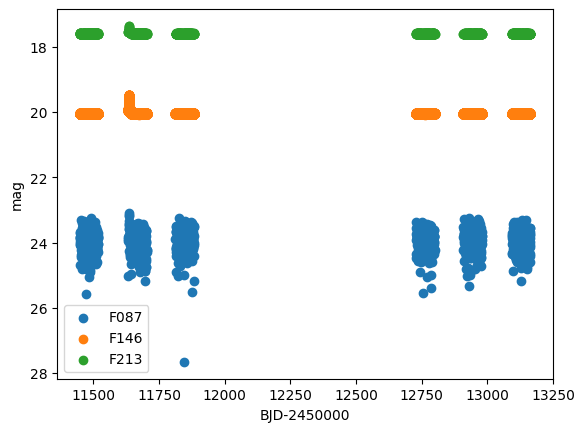

  49,096 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'mag', 'mag_err', 'extinction', 'obs_x', 'obs_y', 'obs_z', 'saturation_flag', 'bjd-2450000']
label:  microlensing
t0:  11635.916989723686
u0:  0.10538280926004105
tE:  5.9305773697679145


/tmp/ipykernel_632/3324247876.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000


=== jacscanomaly summary ===
points      : 46208
seasons     : 6
grid total  : 332628
clusters    : 1171
chi2 / dof  : 1.003

=== best candidate ===
t0          : 11634.664092
teff        : 0.0533333
dchi2       : 278.607
score       : 84.503

=== quality ===
n_window    : 36
n_contrib   : 0
n_eff       : 14.788
peak_frac   : 0.134
rho1        : 0.707
longest_run : 0
   n_points  n_seasons  n_clusters  n_grid_total  chi2_dof  has_best  \
0     46208          6        1171        332628  1.003122      True   

        best_t0  best_teff  best_dchi2  best_score  best_score_n_reference  \
0  11634.664092   0.053333  278.607239   84.503145                     206   

   best_n_window  best_n_contrib  best_n_eff  best_peak_frac  best_rho1  \
0             36               0   14.788347        0.134159   0.706656   

   best_longest_run  
0                 0  
t0_fit_best:  11634.664092166602
best score:  84.50314508944216


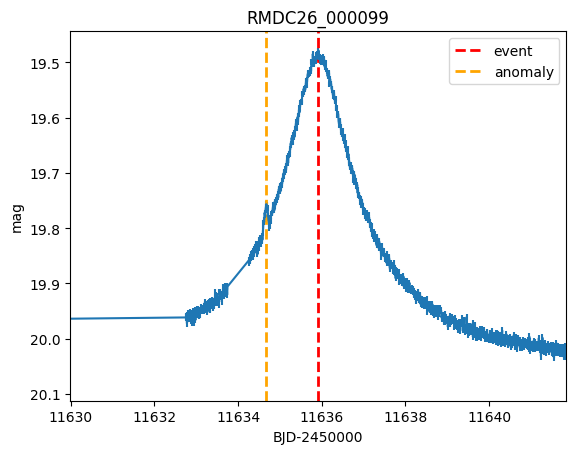

*********************
****   RTModel   ****
*********************
Event name: /teams/mldc-ipacpeople/event_data_chris/event_000099
Number of processors: 32
- Launching: Reader
  Pre-processing data...
  OK
- Launching: InitCond
  Setting initial conditions...
Peaks:  11635.8700  11634.6700  
  OK
- Launching: LevMar
  Fitting PSmyfit ...


In [ ]:
### if you are an admin
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
### if you are not an admin
# root_dir = '/teams/mldc-ipacpeople'

aethra_labels = []
filters = ['F087', 'F146', 'F213']
for EVENT_ID in lc_data_all["name"].unique()[98:]:
    print("Working on: ", EVENT_ID)
    
    # pick out event/light curve
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    actual_id = EVENT_ID.split("_", 1)[1]
    
    # create event directory in the format RTModel wants
    new_event_dir = root_dir + '/event_data_chris/event_' + actual_id
    
    # delete everything cause it was messed up
    try:
        #os.remove(new_event_dir+"/Nature.txt")
        shutil.rmtree(new_event_dir)
    except:
        pass
        
    try:
        os.mkdir(new_event_dir)
    except Exception as e:
        pass
    try:
        os.mkdir(new_event_dir + '/Data/')
    except Exception as e:
        pass

    # each filter should be converted to a .dat file with the following header: # Mag err HJD-2450000
    # furthermore, RTModel is particular about filename structures: .dat files should end with the correct satelllite suffix
    # name schematics follow the schematic from Stela Ishitani Silva's post on WG3 Confluence page
    # https://rgespit.atlassian.net/wiki/spaces/RPTH/pages/154828801/RTModel+v2.4+Runs+for+the+2371+Representative+Sample+Lightcurves
    for filt in filters:
        lc_data_filt = lc_data.loc[lc_data['filt']==filt]#[time_mask]
        lc_data_dat = pd.DataFrame({'Mag': lc_data_filt['mag'], 'err': lc_data_filt['mag_err'], 'HJD-2450000': lc_data_filt['bjd-2450000']})
        if filt=='F087':
            dat_filepath = new_event_dir + '/Data/RomanZ087sat2.dat'
        elif filt=='F146':
            dat_filepath = new_event_dir + '/Data/RomanW146sat1.dat'
        elif filt=='F213':
            dat_filepath = new_event_dir + '/Data/RomanK213sat3.dat'
        with open(dat_filepath, "w", encoding="utf-8") as f:
            f.write("# Mag err HJD-2450000\n")
            lc_data_dat.to_csv(f, sep=' ', header=None, index=False)

        plt.scatter(lc_data_filt['bjd-2450000'], lc_data_filt['mag'], label=filt)
    plt.gca().yaxis.set_inverted(True)
    plt.ylabel('mag')
    plt.xlabel('BJD-2450000')
    plt.legend()
    plt.show()

    # add coordinates in Data/ dir too     
    coords = SkyCoord(ra=lc_data_filt['ra_deg'].values[0]*u.degree, dec=lc_data_filt['dec_deg'].values[0]*u.degree, frame='icrs')
    ra_hms = coords.ra.to_string(unit=u.hourangle, sep=':', pad=True)
    dec_dms = coords.dec.to_string(sep=':', pad=True)
    coord_filepath = new_event_dir + '/Data/event.coordinates'
    with open(coord_filepath, "w", encoding="utf-8") as cf:
        cf.write(f"{ra_hms} {dec_dms}")

    # add limb darkening file in Data/
    limb_dark_filepath = new_event_dir + '/Data/LimbDarkening.txt'
    with open(limb_dark_filepath, "w", encoding="utf-8") as ld:
        ld.write("0.33 \n0.4532 \n0.251")

    ### event detection
    ### now called Aethra: https://github.com/rges-pit/pyAethra
    aethra_config = {
        "time_col": "bjd",
        "mag_col":  "mag",
        "err_col":  "mag_err",
        #"group_col": "name",   # column identifying each object in the table
    }
    aethra_config = load_config(root_dir+"/config/aethra_config.yaml") # courtesy of Katie Vandorou
    
    results_df = load_and_run(lc_data, aethra_config)
    #candidates = results[results["is_candidate"]]

    # old way
    #results_df = load_and_run(lc_data, config, debug=DEBUG)

    # ── Summary ───────────────────────────────────────────────────────────────────
    n = len(results_df)
    label = results_df['label'].iloc[0]
    print("label: ", label)
    aethra_labels.append(label)
    if (label!='microlensing') and (label!='ffp'):
        continue
    # print(f"\nPipeline complete — {n} object(s) processed.")
    # print(f"  veto_periodic:   {results_df['veto_periodic'].sum()}")
    # print(f"  veto_recurrent:  {results_df['veto_recurrent'].sum()}")
    # print(f"  veto_chromatic:  {results_df['veto_chromatic'].sum()}")
    # print(f"  is_variable_star:{results_df['is_variable_star'].sum()}  (scan_candidate + any veto)")
    # print(f"  is_candidate:    {results_df['is_candidate'].sum()}")
    # print(f"  is_ffp_candidate:{results_df['is_ffp_candidate'].sum()}")

    #if (results_df['is_candidate'].sum()==0) & (results_df['is_ffp_candidate'].sum()==0):
    #    continue # skip to next event 
    
    t0_fit = results_df['t0_fit'].iloc[0]
    u0_fit = results_df['u0_fit'].iloc[0]
    tE_fit = results_df['tE_fit'].iloc[0]
    print("t0: ", t0_fit)
    print("u0: ", u0_fit)
    print("tE: ", tE_fit)

    #best_season = results_df['best_season'].iloc[0] # this was when jacscanomaly was finding peaks where there was no data
    #print(best_season)
    #dsfasdfdsf
    #11600, 11750, 11950, 12700, 12850, 13050

    ### anomaly detection
    lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000
    # masks: jacscanomaly only takes the F146 filter
    time_mask = (lc_data["bjd-2450000"] <= t0_fit + tE_fit * 0.5) & (lc_data["bjd-2450000"] >= t0_fit - tE_fit * 0.5)
    filter_mask = lc_data["filt"] == 'F146'
    lc_data_filter_mask = lc_data[filter_mask]
    lc_data_mask = lc_data[time_mask & filter_mask]
    #print("length of masked data: ", len(lc_data_mask), " out of: ", len(lc_data))
    
    # load data (time, flux, flux_err)
    #lc_data_season = lc_data.loc[lc_data['
    time = np.array(lc_data_filter_mask["bjd-2450000"])#[time_mask & filter_mask])
    mag = np.array(lc_data_filter_mask["mag"])#[time_mask & filter_mask])
    magerr = np.array(lc_data_filter_mask["mag_err"])#[time_mask & filter_mask])
    
    # run anomaly finder
    criteria = CandidateCriteria(
        min_dchi2=60.0,
        min_n_eff=2.0,
        #min_n_contrib=2,
        #max_peak_frac=0.8,
    )
    jacscanomaly_config = FinderConfig(
        fitter_kind="pspl",
        candidate_criteria=criteria, # candidate_criteria=CandidateCriteria(min_n_eff=2.0)
        gap=100.0
    )
    finder = Finder(jacscanomaly_config)
    #result = finder.run(time, mag, magerr, data_kind="mag")

    # initial guess is from aethra
    p0 = np.array([t0_fit, tE_fit, u0_fit])  # t0, tE, u0
    result = finder.run(time, mag, magerr, p0, data_kind="mag")
    result.print_summary()
    result_summary = result.summary_table()
    print(result_summary)
    
    ### do a couple checks for no or weak anomaly found 
    if result_summary['has_best'].values[0]==False:
        plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
        plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
        plt.gca().yaxis.set_inverted(True)
        plt.xlim([t0_fit - 5*tE_fit, t0_fit + 5*tE_fit])
        #plt.xlim([11459-20,11459+120])
        #plt.xlim([11630, 11700])
        plt.ylabel('mag')
        plt.xlabel('BJD-2450000')
        plt.title(f"no anomaly: {EVENT_ID}")
        plt.legend()
        plt.show()
        continue
    else:
        pass
    
    t0_fit_best = result_summary['best_t0'].values[0]
    print("t0_fit_best: ", t0_fit_best)
    best_score = result_summary['best_score'].values[0]
    print("best score: ", best_score)
    if best_score < 10:
        print("does not pass score threshold of 10")
        continue

    # # plot to inspect PSPL fit
    # finder.plot_result()
    # finder.plot_anomaly_window()
    # plt.show()

    plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
    plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
    plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
    plt.gca().yaxis.set_inverted(True)
    plt.xlim([t0_fit - 1*tE_fit, t0_fit + 1*tE_fit])
    #plt.xlim([11459-20,11459+120])
    #plt.xlim([11630, 11700])
    #plt.ylim([17.9, 17.6])
    plt.ylabel('mag')
    plt.xlabel('BJD-2450000')
    plt.title(f"{EVENT_ID}")
    plt.legend()
    plt.show()
    
    ### model
    rtm = RTModel.RTModel(new_event_dir) # if I do rtm.run(), this argument is empty
    rtm.set_satellite_dir(root_dir + '/satellitedir')
    rtm.config_Reader(otherseasons=-1) # throw away all other seasons
    rtm.config_InitCond(usesatellite = 1)
    rtm.Reader()
    rtm.InitCond()

    ### normally, I'd do rtm.run(), but if I want to feed in initial parameters, I need to run each model category manually, starting with PS
    # rtm.run(root_dir + '/event_data_chris/event_'+EVENT_ID[-6:])

    # Dave: instead of rho, use t*, which dpeends on the angular radius of the source star and relative proper motion
    # we have a good prior on the distribution of proper motion 
    # angular sizre of source star depends on brightness but has a lot smaller variance than rho
    # often it doesnt make a big difference not having the right rho or t*; this could matter for roman?
    # Katarzyna: for PS fit, maybe rho isn't important; for binary fits, if you detect an anomaly, you know how long it lasts; then you can divide by tE and get an approximation of rho
    # but also Roman will find a lot of events that don't have finite source effects
    # jacscanomaly can provide initial guess for t* rather than rho
    rtm.LevMar('PSmyfit', parameters = [u0_fit, tE_fit, t0_fit, 0.001]) # u0, tE, t0, rho*, where rho* is fiducial, from Bozza+24
    rtm.launch_fits('PS')
    rtm.ModelSelector('PS')
    rtm.launch_fits('PX') # PSPL w/parallax
    rtm.ModelSelector('PX')
    rtm.launch_fits('BS') # 2S1L
    rtm.ModelSelector('BS')
    rtm.launch_fits('BO') # 2S1L w/xallarap
    rtm.ModelSelector('BO')
    rtm.launch_fits('LS') # 1S2L
    rtm.ModelSelector('LS')
    rtm.launch_fits('LX') # 1S2L w/parallax
    rtm.ModelSelector('LX')
    rtm.launch_fits('LO') # 1S2L w/circular orbital motion
    rtm.ModelSelector('LO')
    # there's also:
    # LK: 1S2L w/eccentric orbital motion
    # TS: 1S3L
    # TX: 1S3L w/parallax
    # TO: 1S3L w/circular orbital motion

    rtm.Finalizer()
    print("DONE with : ", EVENT_ID)
    

#### Plot some fits

Mostly so I can visualize what's happening. Also for cool plots for talks.

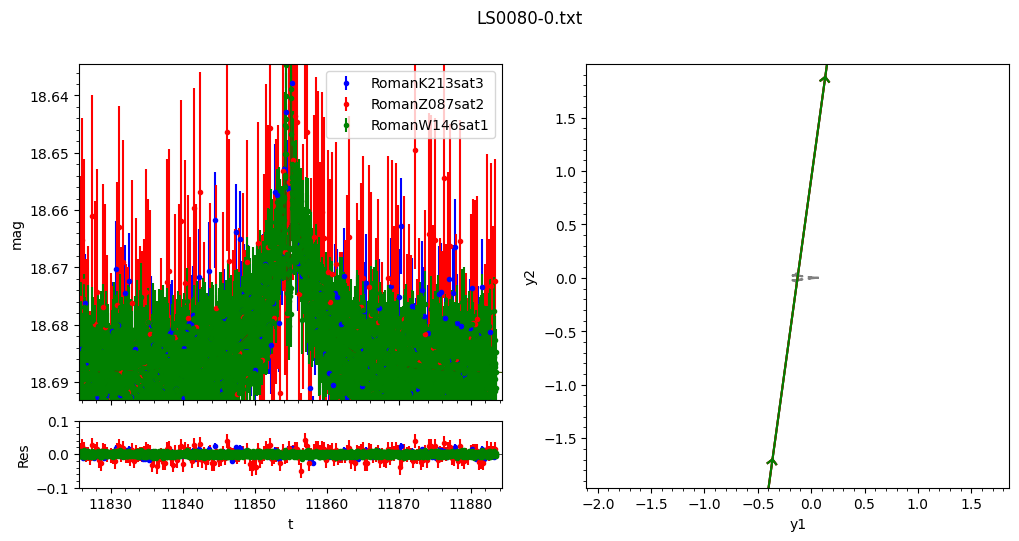

╒════════╤══════════════════════╕
│ chi2   │ 7638.319707813463    │
╞════════╪══════════════════════╡
│ s      │ 0.932483 +- 0.000099 │
├────────┼──────────────────────┤
│ q      │ 0.000707 +- 0.000011 │
├────────┼──────────────────────┤
│ u0     │ 0.12655 +- 0.00015   │
├────────┼──────────────────────┤
│ alpha  │ 4.57504 +- 0.00048   │
├────────┼──────────────────────┤
│ rho    │ 0.000442 +- 0.000040 │
├────────┼──────────────────────┤
│ tE     │ 14.66 +- 0.11        │
├────────┼──────────────────────┤
│ t0     │ 11854.9627 +- 0.0015 │
╘════════╧══════════════════════╛

╒═══════════════╤═══════════════════════╤════════════════╕
│ telescope     │ baseline              │ blending       │
╞═══════════════╪═══════════════════════╪════════════════╡
│ RomanK213sat3 │ 18.688580 +- 0.000018 │ 239.78 +- 0.74 │
├───────────────┼───────────────────────┼────────────────┤
│ RomanZ087sat2 │ 20.830238 +- 0.000019 │ 179.6 +- 1.1   │
├───────────────┼───────────────────────┼────────────────┤
│ RomanW

In [24]:
import glob
import RTModel.plotmodel as plm

root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
eventname = root_dir+'/event_data_chris/event_000005'
models = glob.glob(eventname +'/FinalModels/*')
model = models[1] # let's plot the first of the best models

myplot = plm.plotmodel(eventname = eventname, modelfile = model)
#myplot.telescopes = ['RomanW146sat1']
#myplot.showall()

#### Troubleshoot problematic events

Working on:  RMDC26_000041


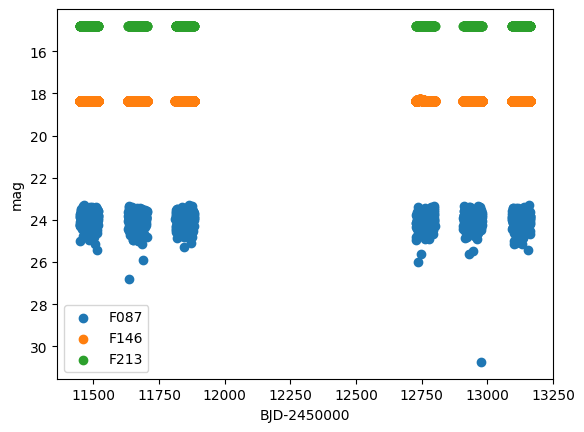

  49,096 rows, columns: ['name', 'l_deg', 'b_deg', 'ra_deg', 'dec_deg', 'bjd', 'filt', 'mag', 'mag_err', 'extinction', 'obs_x', 'obs_y', 'obs_z', 'saturation_flag', 'bjd-2450000']

Pipeline complete — 1 object(s) processed.
  veto_periodic:   1
  veto_recurrent:  1
  veto_chromatic:  0
  is_variable_star:1  (scan_candidate + any veto)
  is_candidate:    0
  is_ffp_candidate:0
t0:  11812.786870722193
u0:  0.007242251122950649
tE:  10.522939935490045


/tmp/ipykernel_613/654136109.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000


=== jacscanomaly summary ===
points      : 46208
seasons     : 6
grid total  : 332628
clusters    : 1057
chi2 / dof  : 21.834

=== best candidate ===
t0          : 12744.833018
teff        : 9.46011
dchi2       : 430828
score       : 3266.562

=== quality ===
n_window    : 4824
n_contrib   : 0
n_eff       : 953.800
peak_frac   : 0.003
rho1        : 0.992
longest_run : 0
   n_points  n_seasons  n_clusters  n_grid_total   chi2_dof  has_best  \
0     46208          6        1057        332628  21.833682      True   

        best_t0  best_teff     best_dchi2   best_score  \
0  12744.833018   9.460106  430828.356391  3266.561929   

   best_score_n_reference  best_n_window  best_n_contrib  best_n_eff  \
0                       2           4824               0  953.800067   

   best_peak_frac  best_rho1  best_longest_run  
0        0.002731   0.991721                 0  
t0_fit_best:  12744.833018415127
Index(['n_points', 'n_seasons', 'n_clusters', 'n_grid_total', 'chi2_dof',
       'has_b

NameError: name 'fasdfadsf' is not defined

In [41]:
root_dir = '/home/mldc-ipacpeople-admin/teams/mldc-ipacpeople'
filters = ['F087', 'F146', 'F213']
problem_events = ['RMDC26_000004','RMDC26_000010','RMDC26_000020','RMDC26_000021','RMDC26_000024','RMDC26_000026',
                 'RMDC26_000027','RMDC26_000032','RMDC26_000036','RMDC26_000037','RMDC26_000041']
for EVENT_ID in problem_events[10:]:
    print("Working on: ", EVENT_ID)
    
    # pick out event/light curve
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    actual_id = EVENT_ID.split("_", 1)[1]
    
    # create event directory in the format RTModel wants
    new_event_dir = root_dir + '/event_data/event_' + actual_id
    try:
        os.mkdir(new_event_dir)
    except Exception as e:
        pass
    try:
        os.mkdir(new_event_dir + '/Data/')
    except Exception as e:
        pass

    # each filter should be converted to a .dat file with the following header: # Mag err HJD-2450000
    # furthermore, RTModel is particular about filename structures: .dat files should end with the correct satelllite suffix
    # name schematics follow the schematic from Stela Ishitani Silva's post on WG3 Confluence page
    # https://rgespit.atlassian.net/wiki/spaces/RPTH/pages/154828801/RTModel+v2.4+Runs+for+the+2371+Representative+Sample+Lightcurves
    for filt in filters:
        lc_data_filt = lc_data.loc[lc_data['filt']==filt]#[time_mask]
        lc_data_dat = pd.DataFrame({'Mag': lc_data_filt['mag'], 'err': lc_data_filt['mag_err'], 'HJD-2450000': lc_data_filt['bjd-2450000']})
        if filt=='F087':
            dat_filepath = new_event_dir + '/Data/RomanZ087sat2.dat'
        elif filt=='F146':
            dat_filepath = new_event_dir + '/Data/RomanW146sat1.dat'
        elif filt=='F213':
            dat_filepath = new_event_dir + '/Data/RomanK213sat3.dat'
        with open(dat_filepath, "w", encoding="utf-8") as f:
            f.write("# Mag err HJD-2450000\n")
            lc_data_dat.to_csv(f, sep=' ', header=None, index=False)

        plt.scatter(lc_data_filt['bjd-2450000'], lc_data_filt['mag'], label=filt)
    plt.gca().yaxis.set_inverted(True)
    plt.ylabel('mag')
    plt.xlabel('BJD-2450000')
    plt.legend()
    plt.show()

    # add coordinates in Data/ dir too     
    coords = SkyCoord(ra=lc_data_filt['ra_deg'].values[0]*u.degree, dec=lc_data_filt['dec_deg'].values[0]*u.degree, frame='icrs')
    ra_hms = coords.ra.to_string(unit=u.hourangle, sep=':', pad=True)
    dec_dms = coords.dec.to_string(sep=':', pad=True)
    coord_filepath = new_event_dir + '/Data/event.coordinates'
    with open(coord_filepath, "w", encoding="utf-8") as cf:
        cf.write(f"{ra_hms} {dec_dms}")

    # add limb darkening file in Data/
    limb_dark_filepath = new_event_dir + '/Data/LimbDarkening.txt'
    with open(limb_dark_filepath, "w", encoding="utf-8") as ld:
        ld.write("0.33 \n0.4532 \n0.251")

    ### event detection
    ### now called Aethra: https://github.com/rges-pit/aethra
    aethra_config = {
        "time_col": "bjd",
        "mag_col":  "mag",
        "err_col":  "mag_err",
        #"group_col": "name",   # column identifying each object in the table
    }
    #aethra_config = load_config("config.yaml")
    
    results_df = load_and_run(lc_data, aethra_config)
    #candidates = results[results["is_candidate"]]

    # old way
    #results_df = load_and_run(lc_data, config, debug=DEBUG)

    # ── Summary ───────────────────────────────────────────────────────────────────
    n = len(results_df)
    print(f"\nPipeline complete — {n} object(s) processed.")
    print(f"  veto_periodic:   {results_df['veto_periodic'].sum()}")
    print(f"  veto_recurrent:  {results_df['veto_recurrent'].sum()}")
    print(f"  veto_chromatic:  {results_df['veto_chromatic'].sum()}")
    print(f"  is_variable_star:{results_df['is_variable_star'].sum()}  (scan_candidate + any veto)")
    print(f"  is_candidate:    {results_df['is_candidate'].sum()}")
    print(f"  is_ffp_candidate:{results_df['is_ffp_candidate'].sum()}")

    #if (results_df['is_candidate'].sum()==0) & (results_df['is_ffp_candidate'].sum()==0):
    #    continue # skip to next event 
    
    t0_fit = results_df['t0_fit'].iloc[0]
    u0_fit = results_df['u0_fit'].iloc[0]
    tE_fit = results_df['tE_fit'].iloc[0]
    print("t0: ", t0_fit)
    print("u0: ", u0_fit)
    print("tE: ", tE_fit)

    #best_season = results_df['best_season'].iloc[0] # this was when jacscanomaly was finding peaks where there was no data
    #print(best_season)
    #dsfasdfdsf
    #11600, 11750, 11950, 12700, 12850, 13050

    ### anomaly detection
    lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000
    # masks: jacscanomaly only takes the F146 filter
    time_mask = (lc_data["bjd-2450000"] <= t0_fit + tE_fit * 5) & (lc_data["bjd-2450000"] >= t0_fit - tE_fit * 5)
    filter_mask = lc_data["filt"] == 'F146'
    lc_data_filter_mask = lc_data[filter_mask]
    lc_data_mask = lc_data[time_mask & filter_mask]
    #print("length of masked data: ", len(lc_data_mask), " out of: ", len(lc_data))
    
    # load data (time, flux, flux_err)
    #lc_data_season = lc_data.loc[lc_data['
    time = np.array(lc_data_filter_mask["bjd-2450000"])#[time_mask & filter_mask])
    mag = np.array(lc_data_filter_mask["mag"])#[time_mask & filter_mask])
    magerr = np.array(lc_data_filter_mask["mag_err"])#[time_mask & filter_mask])
    
    # run anomaly finder
    criteria = CandidateCriteria(
        min_dchi2=60.0,
        min_n_eff=2.0,
        #min_n_contrib=2,
        #max_peak_frac=0.8,
    )
    jacscanomaly_config = FinderConfig(
        fitter_kind="pspl",
        candidate_criteria=criteria, # candidate_criteria=CandidateCriteria(min_n_eff=2.0)
        gap=100.0
    )
    finder = Finder(jacscanomaly_config)
    #result = finder.run(time, mag, magerr, data_kind="mag")

    # initial guess is from aethra
    p0 = np.array([t0_fit, tE_fit, u0_fit])  # t0, tE, u0
    result = finder.run(time, mag, magerr, p0, data_kind="mag")
    #result = finder.run(time, mag, magerr, data_kind="mag") # run jacscanomaly's own PSPL fit
    result.print_summary()
    result_summary = result.summary_table()
    print(result_summary)
    t0_fit_best = result_summary['best_t0'].values[0]
    print("t0_fit_best: ", t0_fit_best)
    best_score = result_summary['best_score'].values[0]
    print("best score: ", best_score)

    # # plot to inspect PSPL fit
    # finder.plot_result()
    # finder.plot_anomaly_window()
    # plt.show()
    
    plt.errorbar(lc_data_filter_mask['bjd-2450000'], lc_data_filter_mask['mag'], lc_data_filter_mask['mag_err'], )
    plt.axvline(x=t0_fit, color='red', linestyle='--', linewidth=2, label='event')
    plt.axvline(x=t0_fit_best, color='orange', linestyle='--', linewidth=2, label='anomaly')
    plt.gca().yaxis.set_inverted(True)
    #plt.xlim([t0_fit - 5*tE_fit, t0_fit + 5*tE_fit])
    #plt.xlim([11459-20,11459+120])
    plt.xlim([11750, 12850])
    plt.ylabel('mag')
    plt.xlabel('BJD-2450000')
    plt.title(f"{EVENT_ID}")
    plt.legend()
    plt.show()
    jhkjhlkj
    
    ### model
    rtm = RTModel.RTModel()
    rtm.set_satellite_dir(root_dir + '/satellitedir')
    rtm.config_Reader(otherseasons=-1) # throw away all other seasons
    rtm.config_InitCond(usesatellite = 1)
    rtm.run(root_dir + '/event_data/event_'+EVENT_ID[-6:])

    print("DONE with : ", EVENT_ID)
    

#### Event detection

In [ ]:
from eventfinder import load_and_run, _read_table_file, run_pipeline_from_dataframe

In [ ]:
# ── REQUIRED: column names ────────────────────────────────────────────────────
TIME_COL = "bjd"      # barycentric julian date (or any time column)
MAG_COL  = "mag"      # magnitude
ERR_COL  = "mag_err"  # magnitude uncertainty

# ── INPUT PATH ────────────────────────────────────────────────────────────────
# Set to ONE of:
#   str  → a single file path OR a glob pattern for per-object files
#           e.g. "data.parquet", "data.csv", "data.fits", "lc/*.txt"
#   tuple of two glob strings → paired per-filter files matched by stem
#           e.g. ("lc/*_W149.txt", "lc/*_Z087.txt")
#   pd.DataFrame → already-loaded table (assign before running)
#INPUT_PATH = ("../../2018-dataChallenge/lc/*_W149.txt", "../../2018-dataChallenge/lc/*_Z087.txt")   # ← change to your file
INPUT_PATH = lc_data.loc[(lc_data['bjd'] > 2461664) & (lc_data['bjd'] < 2461684.8)]

# ── TEXT FILE OPTIONS (ignored for parquet / fits / in-memory DataFrame) ──────
# COLUMNS: list of names when the file has NO header row; None = file has a header
COLUMNS = ["bjd", "mag", "mag_err"]
SEP     = r"\s+"   # column separator regex; use "," for CSV
HEADER  = None     # None = no header row; 0 = first row is header

# ── GROUPING ──────────────────────────────────────────────────────────────────
# Column whose unique values identify each source (e.g. "name", "object_id").
# Set to None when each file / DataFrame contains exactly one object.
GROUP_COL = None   # parquet with many objects → "name"; per-object txt files → None

# ── FILTER OPTIONS ────────────────────────────────────────────────────────────
# Set FILTER_COL = None if your data has no filter column.
# The achromatic test is then skipped automatically.
FILTER_COL        = None #"filt"        # column name for filter labels; None → skip achromatic test
TARGET_FILTER     = "W149"        # filter used for event detection (primary band)
PRIMARY_FILTER    = "W149"        # primary filter for achromatic test
# One secondary band:   SECONDARY_FILTERS = "F087"
# Two secondary bands:  SECONDARY_FILTERS = ["F087", "F213"]
# Old paired-file data: SECONDARY_FILTERS = "Z087"
SECONDARY_FILTERS = ["Z087"]

# ── PIPELINE TUNING ───────────────────────────────────────────────────────────
MIN_POINTS        = 10     # minimum points per season to run analysis
FAP_THRESHOLD     = 0.01   # false-alarm probability threshold for periodicity veto
SEASON_GAP_DAYS   = 100    # day gap that separates observing seasons
FFP_TE_MAX        = 2.0    # max tE (days) to flag as free-floating planet candidate
GOOD_PSPL_CHI2    = 2.5    # reduced χ² threshold for an acceptable PSPL fit
CHROMATIC_MIN_PTS = 5      # min points per filter band for achromatic test

# ── OUTPUT ────────────────────────────────────────────────────────────────────
OUTPUT_CSV = None   # path to save results CSV; None = don't save

In [ ]:
config = {
    "time_col":   TIME_COL,
    "mag_col":    MAG_COL,
    "err_col":    ERR_COL,
    "columns":    COLUMNS,
    "sep":        SEP,
    "header":     HEADER,
    "group_col":  GROUP_COL,
    "filter_col": FILTER_COL,
    "target_filter":        TARGET_FILTER,
    "primary_filter":       PRIMARY_FILTER,
    "secondary_filters":    SECONDARY_FILTERS,
    "min_points":           MIN_POINTS,
    "fap_threshold":        FAP_THRESHOLD,
    "season_gap_days":      SEASON_GAP_DAYS,
    "ffp_tE_max":           FFP_TE_MAX,
    "good_pspl_chi2":       GOOD_PSPL_CHI2,
    "chromatic_min_points": CHROMATIC_MIN_PTS,
}

# Set DEBUG = True to print per-object veto breakdown while running.
# For large datasets, set to False or limit to a subset first.
DEBUG = False

results_df = load_and_run(INPUT_PATH, config, debug=DEBUG)

# ── Summary ───────────────────────────────────────────────────────────────────
n = len(results_df)
print(f"\nPipeline complete — {n} object(s) processed.")
print(f"  veto_periodic:   {results_df['veto_periodic'].sum()}")
print(f"  veto_recurrent:  {results_df['veto_recurrent'].sum()}")
print(f"  veto_chromatic:  {results_df['veto_chromatic'].sum()}")
print(f"  is_variable_star:{results_df['is_variable_star'].sum()}  (scan_candidate + any veto)")
print(f"  is_candidate:    {results_df['is_candidate'].sum()}")
print(f"  is_ffp_candidate:{results_df['is_ffp_candidate'].sum()}")

if OUTPUT_CSV:
    results_df.to_csv(OUTPUT_CSV, index=False)
    print(f"  Saved → {OUTPUT_CSV}")

t0_fit = results_df['t0_fit'].iloc[0]
u0_fit = results_df['u0_fit'].iloc[0]
tE_fit = results_df['tE_fit'].iloc[0]
print("t0: ", t0_fit)
print("u0: ", u0_fit)
print("tE: ", tE_fit)

In [ ]:
t0_fit

In [ ]:
time_mask = (lc_data["bjd"] - 2450000 <= t0_fit + tE_fit * 5) & (lc_data["bjd"] - 2450000 >= t0_fit - tE_fit * 5)
print(len(time_mask))

In [ ]:
plt.figure(figsize=(8, 5))
band = 'F146'
filter_mask = lc_data["filt"] == band
# plt.errorbar(
#     lc_data[keys["time"]][mask] - 2450000, lc_data["mag"][mask], yerr=lc_data["mag_err"][mask],
#     fmt=".", label=f"Band {band}", alpha=0.7
# )
plt.errorbar(
    lc_data["bjd"][time_mask & filter_mask], lc_data["mag"][time_mask & filter_mask], yerr=lc_data["mag_err"][time_mask & filter_mask],
    fmt=".", label=f"Band {band}", alpha=0.7
)
plt.gca().invert_yaxis()
plt.title(f"{EVENT_ID} Light Curve")
plt.xlabel("HJD")
plt.ylabel("Magnitude")
#plt.xlim([t0_fit - tE_fit * 2, t0_fit + tE_fit * 2]) # [2461664, 2461674.8]
#plt.ylim([19.45, 19.28])
plt.show()

#### Anomaly detection

In [ ]:
from jacscanomaly import CandidateCriteria, Finder, FinderConfig

In [ ]:
lc_data['bjd-2450000'] = lc_data['bjd'] - 2450000

In [ ]:
# load data (time, flux, flux_err)
time = np.array(lc_data["bjd-2450000"][time_mask & filter_mask])
mag = np.array(lc_data["mag"][time_mask & filter_mask])
magerr = np.array(lc_data["mag_err"][time_mask & filter_mask])
print(time)
print(mag)
print(magerr)

# run anomaly finder
config = FinderConfig(
    fitter_kind="pspl",
    candidate_criteria=CandidateCriteria(min_n_eff=2.0),
)
finder = Finder(config)
result = finder.run(time, mag, magerr, data_kind="mag")
#result = finder.run(time, flux, ferr)

# You can still pass an explicit initial guess if desired:
# p0 = np.array([10000, 10, 0.3])
# result = finder.run(time, flux, ferr, p0)

result.print_summary()

In [ ]:
### window of interest = |t0_anomaly - t0_event| 

#### Modeling

In [7]:
# from the data file comments we know that: #fs:
fs = np.array([0.0858942, 0.991581, 0.000266992])
Obssrcmag = np.array([23.6466, 24.2485, 23.7078])

for EVENT_ID in lc_data_all["name"].unique():
    lc_data = lc_data_all[lc_data_all["name"] == EVENT_ID]
    
    keys = {}
    keys["time"] = "bjd"
    keys["flux"] = None  # not provided in the Experienced and Beginner Tiers
    keys["flux_err"] = None  # not provided in the Experienced and Beginner
    keys["band"] = "filt"

    # Get unique bands (`observatory_code` or `filt`)
    bands = np.sort(np.unique(lc_data[keys["band"]].to_numpy())) # will usually be all three of 'F087' 'F146' 'F213', but not always?

    lc_data = helpers.gulls_flux_to_mag(lc_data, fs, Obssrcmag, bands, keys)
    print(lc_data)
    adsfadf

    


                name     l_deg     b_deg     ra_deg    dec_deg           bjd  \
0      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
1      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
2      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461448e+06   
3      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461449e+06   
4      RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.461449e+06   
...              ...       ...       ...        ...        ...           ...   
49091  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463163e+06   
49092  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49093  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49094  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   
49095  RMDC26_000001 -0.209139 -1.912896  268.16625 -30.099826  2.463164e+06   

       filt        mag   mag_err  extin

NameError: name 'adsfadf' is not defined